# PCOSense Exploratory Data Analysis

This notebook examines the dataset distributions, class balance, feature relationships and possible outliers before model training.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "PCOS_data_without_infertility.xlsx"
)

df = pd.read_excel(DATA_PATH, sheet_name="Full_new")

df.columns = (
    df.columns
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df = df.drop(columns=["Unnamed: 44"])

print("Dataset shape:", df.shape)

Dataset shape: (541, 44)


In [3]:
for column in ["II beta-HCG(mIU/mL)", "AMH(ng/mL)"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print(df[["II beta-HCG(mIU/mL)", "AMH(ng/mL)"]].dtypes)
print(df[["II beta-HCG(mIU/mL)", "AMH(ng/mL)"]].isna().sum())

II beta-HCG(mIU/mL)    float64
AMH(ng/mL)             float64
dtype: object
II beta-HCG(mIU/mL)    1
AMH(ng/mL)             1
dtype: int64


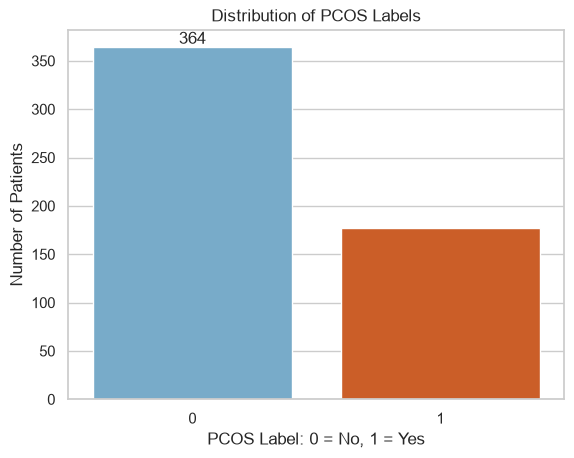

PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64

In [4]:
target_counts = df["PCOS (Y/N)"].value_counts().sort_index()

ax = sns.countplot(
    data=df,
    x="PCOS (Y/N)",
    hue="PCOS (Y/N)",
    palette=["#6baed6", "#e6550d"],
    legend=False
)

ax.set_title("Distribution of PCOS Labels")
ax.set_xlabel("PCOS Label: 0 = No, 1 = Yes")
ax.set_ylabel("Number of Patients")
ax.bar_label(ax.containers[0])

plt.show()

display(target_counts)

### Target distribution observation

The dataset contains 364 PCOS-negative and 177 PCOS-positive records. The target is mildly imbalanced, so model evaluation should not rely on accuracy alone. Precision, recall, F1, ROC-AUC and PR-AUC will also be reported.

In [5]:
symptom_columns = [
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)"
]

symptom_rates = (
    df.groupby("PCOS (Y/N)")[symptom_columns]
    .mean()
    .T
    .mul(100)
    .round(2)
)

symptom_rates.columns = ["No PCOS (%)", "PCOS (%)"]
display(symptom_rates)

,No PCOS (%),PCOS (%)
Weight gain(Y/N),22.80,68.36
hair growth(Y/N),12.91,57.06
Skin darkening (Y/N),15.38,62.15
Hair loss(Y/N),39.29,57.63
Pimples(Y/N),39.01,69.49
Fast food (Y/N),38.29,78.53
Reg.Exercise(Y/N),22.80,28.81


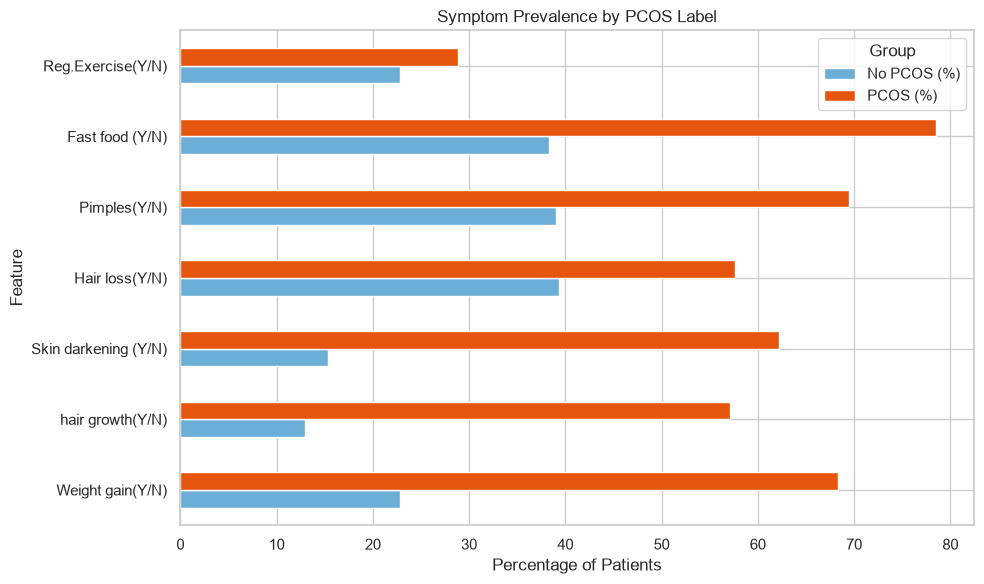

In [6]:
ax = symptom_rates.plot(
    kind="barh",
    figsize=(10, 6),
    color=["#6baed6", "#e6550d"]
)

ax.set_title("Symptom Prevalence by PCOS Label")
ax.set_xlabel("Percentage of Patients")
ax.set_ylabel("Feature")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

In [7]:
numerical_features = [
    "Age (yrs)",
    "BMI",
    "Cycle length(days)",
    "AMH(ng/mL)",
    "Follicle No. (L)",
    "Follicle No. (R)"
]

group_summary = (
    df.groupby("PCOS (Y/N)")[numerical_features]
    .median()
    .T
)

group_summary.columns = ["No PCOS median", "PCOS median"]
display(group_summary)

,No PCOS median,PCOS median
Age (yrs),32.0,29.0
BMI,23.6,25.1
Cycle length(days),5.0,5.0
AMH(ng/mL),3.2,5.9
Follicle No. (L),4.0,10.0
Follicle No. (R),4.0,11.0


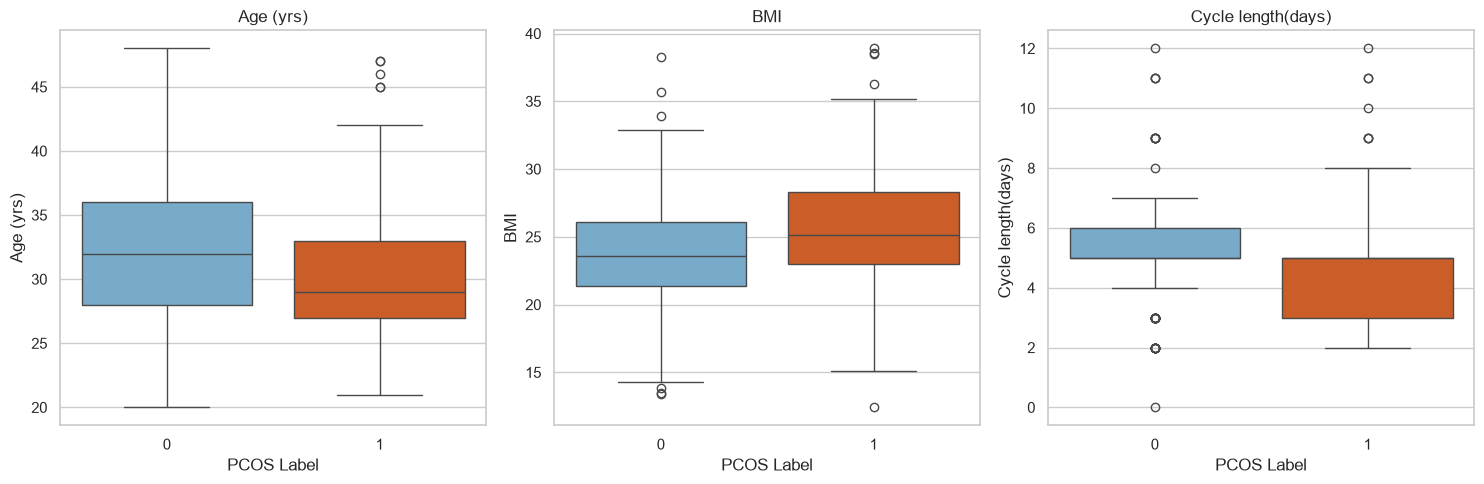

In [8]:
features_to_plot = [
    "Age (yrs)",
    "BMI",
    "Cycle length(days)"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for axis, feature in zip(axes, features_to_plot):
    sns.boxplot(
        data=df,
        x="PCOS (Y/N)",
        y=feature,
        hue="PCOS (Y/N)",
        palette=["#6baed6", "#e6550d"],
        legend=False,
        ax=axis
    )
    axis.set_title(feature)
    axis.set_xlabel("PCOS Label")

plt.tight_layout()
plt.show()

### Initial feature observations

- The PCOS-labelled group has a lower median age and higher median BMI.
- Weight gain, hair growth, skin darkening, hair loss and pimples are more common in the PCOS-labelled group.
- Fast-food reporting is also more common, but this is an association and should not be interpreted as a cause.
- Median AMH and follicle counts are notably higher in the PCOS-labelled group.
- Median cycle length is five days in both groups, although their distributions differ.
- Regular exercise shows only a small difference between the groups.

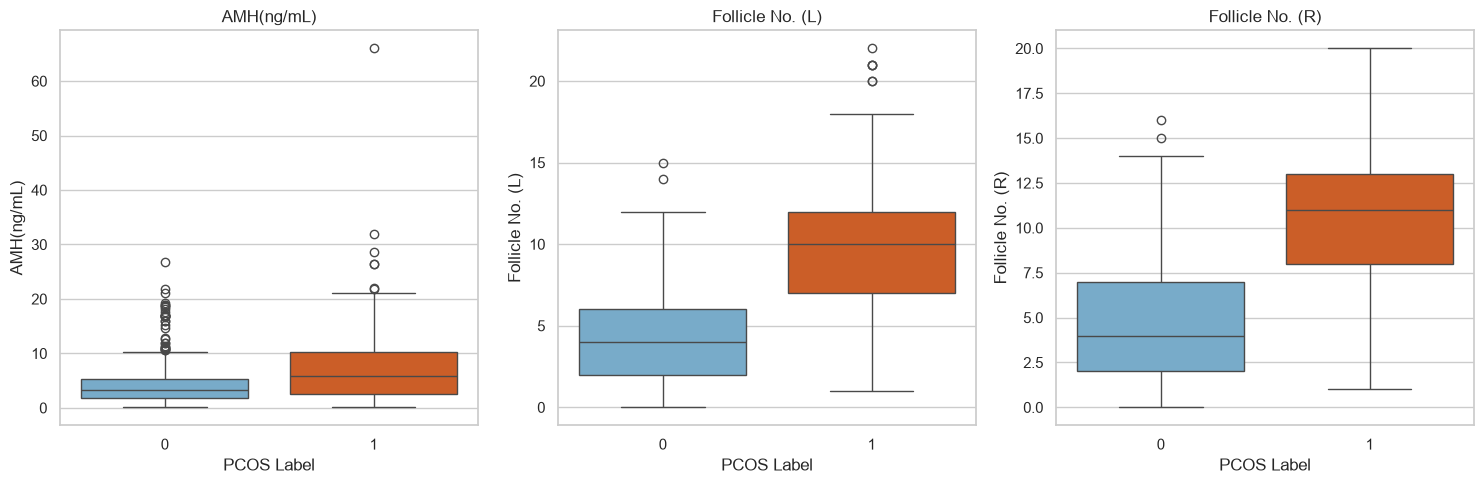

In [10]:
clinical_features = [
    "AMH(ng/mL)",
    "Follicle No. (L)",
    "Follicle No. (R)"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for axis, feature in zip(axes, clinical_features):
    sns.boxplot(
        data=df,
        x="PCOS (Y/N)",
        y=feature,
        hue="PCOS (Y/N)",
        palette=["#6baed6", "#e6550d"],
        legend=False,
        ax=axis
    )
    axis.set_title(feature)
    axis.set_xlabel("PCOS Label")

plt.tight_layout()
plt.show()

In [11]:
model_columns = df.drop(
    columns=["Sl. No", "Patient File No."]
)

target_correlations = (
    model_columns
    .corr(method="spearman", numeric_only=True)["PCOS (Y/N)"]
    .drop("PCOS (Y/N)")
    .sort_values(key=abs, ascending=False)
)

display(target_correlations.head(15))

Follicle No. (R)        0.627988
Follicle No. (L)        0.580721
Skin darkening (Y/N)    0.475733
hair growth(Y/N)        0.464667
Weight gain(Y/N)        0.441047
Cycle(R/I)              0.401242
Fast food (Y/N)         0.377933
Pimples(Y/N)            0.286077
Cycle length(days)     -0.250131
AMH(ng/mL)              0.236723
BMI                     0.196164
Weight (Kg)             0.195036
Age (yrs)              -0.185300
Waist(inch)             0.174886
Hair loss(Y/N)          0.172879
Name: PCOS (Y/N), dtype: float64

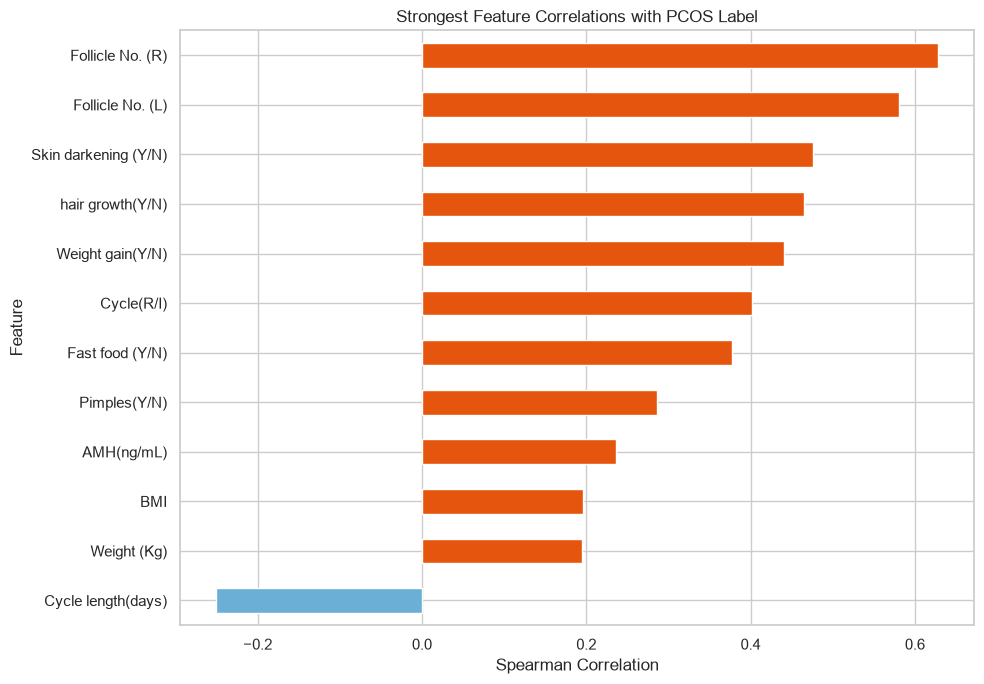

In [12]:
top_correlations = target_correlations.head(12).sort_values()

colors = [
    "#e6550d" if value > 0 else "#6baed6"
    for value in top_correlations
]

ax = top_correlations.plot(
    kind="barh",
    figsize=(10, 7),
    color=colors
)

ax.set_title("Strongest Feature Correlations with PCOS Label")
ax.set_xlabel("Spearman Correlation")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

### Leakage warning

Follicle counts and other ultrasound measurements may have contributed to the original clinical PCOS labels. Their strong relationship with the target may therefore represent diagnostic circularity rather than independent predictive discovery. Later models will compare screening-style features against the full clinical feature set.

### Correlation observations

- Left and right follicle counts have the strongest correlations with the PCOS label.
- This supports the concern that ultrasound measurements may partially reproduce the clinical labelling process.
- Skin darkening, hair growth, weight gain and cycle irregularity show the strongest non-ultrasound associations.
- Cycle length and age have negative correlations with the label.
- Correlation shows association, not causation.

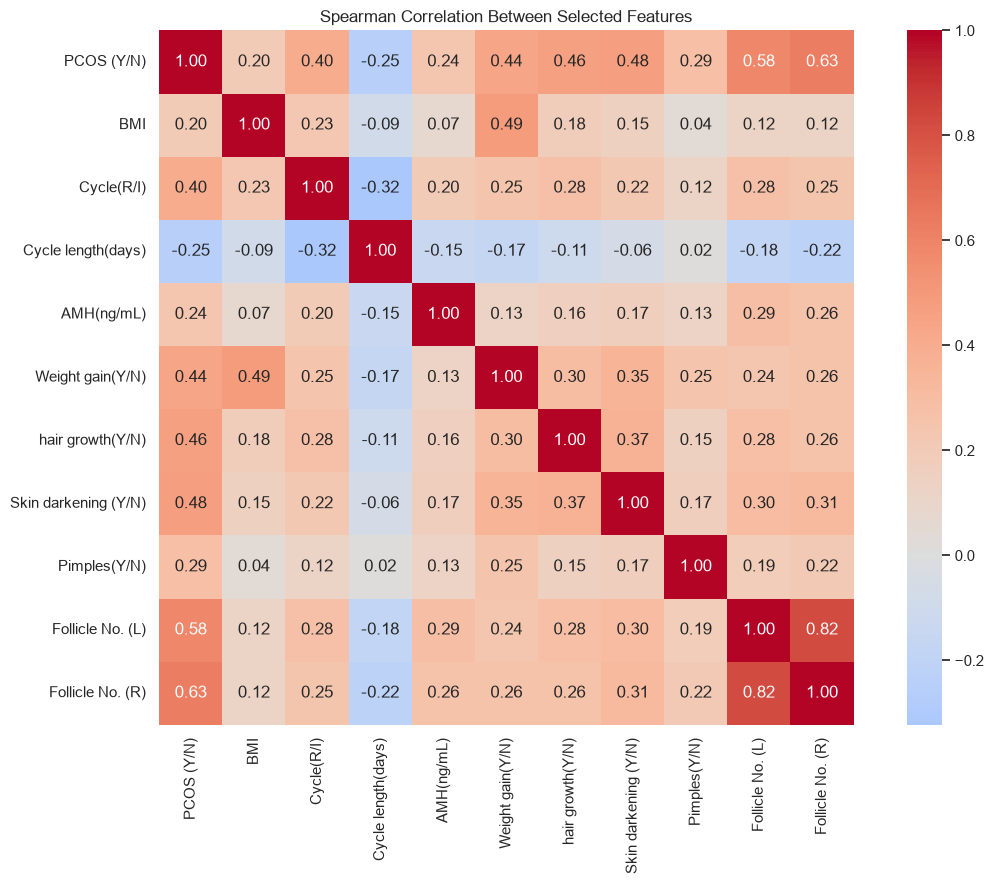

In [13]:
heatmap_features = [
    "PCOS (Y/N)",
    "BMI",
    "Cycle(R/I)",
    "Cycle length(days)",
    "AMH(ng/mL)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Pimples(Y/N)",
    "Follicle No. (L)",
    "Follicle No. (R)"
]

correlation_matrix = df[heatmap_features].corr(method="spearman")

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Spearman Correlation Between Selected Features")
plt.tight_layout()
plt.show()

In [14]:
missing_report = pd.DataFrame({
    "Missing count": df.isna().sum(),
    "Missing percentage": (df.isna().mean() * 100).round(2)
})

missing_report = missing_report[
    missing_report["Missing count"] > 0
].sort_values("Missing count", ascending=False)

display(missing_report)

,Missing count,Missing percentage
Marraige Status (Yrs),1,0.18
II beta-HCG(mIU/mL),1,0.18
AMH(ng/mL),1,0.18
Fast food (Y/N),1,0.18


## EDA conclusion

The dataset shows meaningful differences between the PCOS-labelled and non-PCOS groups. Symptoms such as hair growth, skin darkening and weight gain are more common in the positive group. AMH and ultrasound follicle counts are also higher.

Ultrasound follicle counts have the strongest relationship with the target, creating a risk of diagnostic leakage. Therefore, the modelling stage will compare a screening-style feature set without ultrasound against a full clinical feature set.

Missingness is minimal, but invalid text values and suspected measurement errors must be handled inside a reproducible preprocessing pipeline.